# Income Dataset — KMeans Clustering
### Dataset: UCI Adult / Census Income Dataset

---

This notebook continues from the Logistic Regression classifier. We now apply **unsupervised learning** using **KMeans Clustering** to discover natural groupings in the data — without using the `label` column.

Unlike Logistic Regression, clustering does not predict a known target. Instead it asks: *given the features alone, do people naturally group together in any meaningful way?*

**Workflow:**
1. Import libraries
2. Load and preprocess the dataset
3. Scale features
4. Find the optimal number of clusters (Elbow Method)
5. Fit the KMeans model
6. Analyse and visualise the clusters
7. Compare clusters against the actual income labels

---

## Step 1 — Import Libraries

We add `KMeans` and `PCA` to our standard imports:

| Library | Purpose |
|---|---|
| `KMeans` | The clustering algorithm |
| `PCA` | Reduces high-dimensional data to 2D so we can plot clusters |
| `silhouette_score` | Measures how well-separated the clusters are (score between -1 and 1) |
| All others | Same as the previous notebook — data loading, encoding, scaling, plotting |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')


## Step 2 — Load and Preprocess the Dataset

We repeat the same loading and preprocessing pipeline from the previous notebook:
1. Strip the outer double-quotes from each row
2. Replace `?` placeholders with `NaN` and drop incomplete rows
3. Label-encode all categorical columns

We keep a copy of the original `label` column **before** dropping it from features. We will use it later to check whether our clusters align with the real income groups.

In [5]:
# Load and parse the CSV
with open('income_prediction.csv') as f:
    lines = f.read().splitlines()

clean_lines = [line.strip('"') for line in lines]
df = pd.read_csv(io.StringIO('\n'.join(clean_lines)), skipinitialspace=True)
df.columns = df.columns.str.strip()

# Handle missing values
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

print(f'Dataset ready: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Dataset ready: 30,162 rows x 15 columns


,Age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,label
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,0


### Separate Features from the Label

KMeans is **unsupervised** — it does not use the target variable during training.

We:
- Store the `label` column separately as `true_labels` (for evaluation later)
- Drop `label` from the features so the model clusters purely on input data

In [7]:
# Store actual income labels for later comparison
true_labels = df['label'].copy()

# Features only — no label
X = df.drop('label', axis=1)

print('Features shape:', X.shape)
print('Label classes  :', true_labels.unique())


Features shape: (30162, 14)
Label classes  : [0 1]


## Step 3 — Scale the Features

Scaling is even more critical for KMeans than for Logistic Regression.

KMeans works by measuring **Euclidean distance** between data points and cluster centres. If one feature (e.g. `fnlwgt`) has values in the hundreds of thousands while another (e.g. `sex`) is 0 or 1, the large-scale feature will completely dominate the distance calculation — and the other features become meaningless.

`StandardScaler` brings every feature to **mean = 0, std = 1** so all features contribute equally to the distance calculation.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaling complete.')
print(f'Mean of first feature (should be ~0): {X_scaled[:, 0].mean():.4f}')
print(f'Std  of first feature (should be ~1): {X_scaled[:, 0].std():.4f}')


Scaling complete.
Mean of first feature (should be ~0): 0.0000
Std  of first feature (should be ~1): 1.0000


## Step 4 — Find the Optimal Number of Clusters (Elbow Method)

KMeans requires us to choose **k** (the number of clusters) in advance. There is no single correct answer — we use the **Elbow Method** to find a sensible value.

**How it works:**
1. Run KMeans for k = 1, 2, 3, ... up to 10
2. For each k, record the **inertia** — the total sum of squared distances from each point to its assigned cluster centre
3. Plot inertia vs k

As k increases, inertia always decreases — adding more clusters always reduces the sum of distances. The **elbow point** is where the rate of improvement sharply slows down. That bend in the curve is the sweet spot: adding more clusters beyond it gives diminishing returns.

`random_state=42` ensures reproducible results. `n_init=10` runs the algorithm 10 times with different starting points and picks the best result.

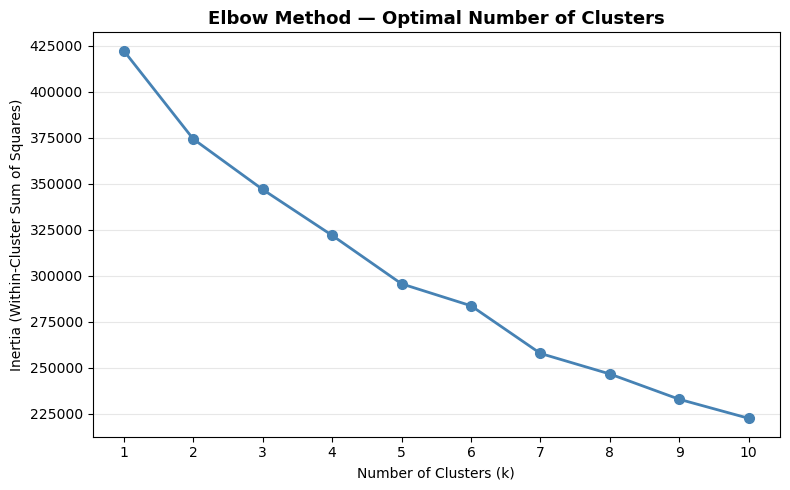

In [11]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=7)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Step 5 — Silhouette Scores

The Elbow Method is visual and sometimes ambiguous. The **Silhouette Score** gives a numeric measure of cluster quality.

For each data point, it measures:
- How close the point is to others in its **own cluster** (cohesion)
- How far it is from points in the **nearest other cluster** (separation)

The score ranges from **-1 to +1**:
- **Close to +1** → the point is well inside its cluster and far from others (good)
- **Close to 0** → the point is near a cluster boundary (ambiguous)
- **Negative** → the point may have been assigned to the wrong cluster (bad)

We skip k=1 since silhouette requires at least 2 clusters.

k= 2  silhouette score: 0.1352
k= 3  silhouette score: 0.1518
k= 4  silhouette score: 0.1598
k= 5  silhouette score: 0.1641
k= 6  silhouette score: 0.1537
k= 7  silhouette score: 0.1673
k= 8  silhouette score: 0.1302
k= 9  silhouette score: 0.1346
k=10  silhouette score: 0.1305


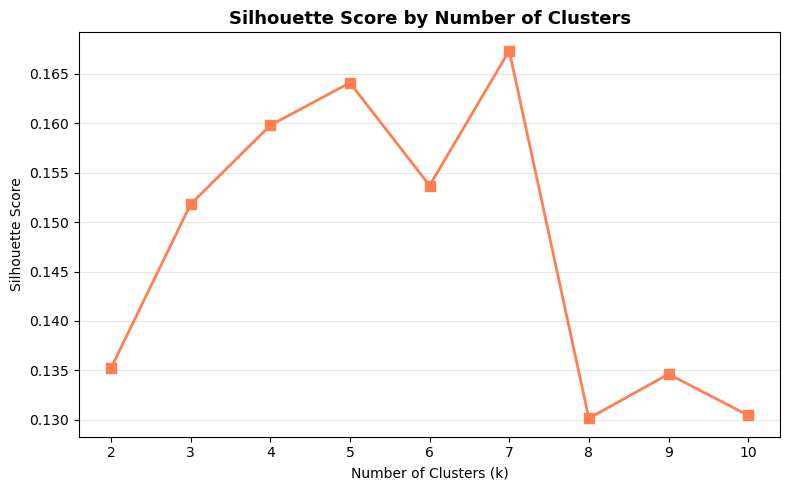

k= 8  silhouette score: 0.1302


k= 9  silhouette score: 0.1346


k=10  silhouette score: 0.1305


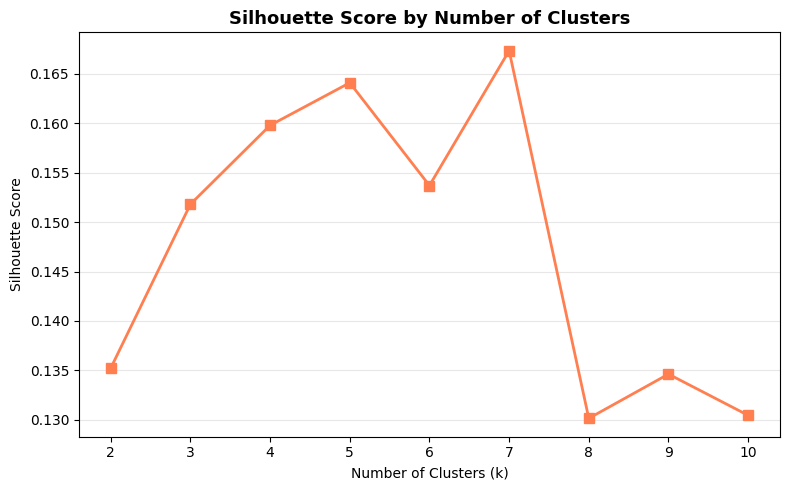

In [13]:
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(score)
    print(f'k={k:2d}  silhouette score: {score:.4f}')

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker='s', color='coral', linewidth=2, markersize=7)
plt.title('Silhouette Score by Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6 — Fit the KMeans Model

Based on both the Elbow curve and Silhouette scores, we select **k = 2**.

This is also a natural choice given what we know about the data — the original problem was binary (`<=50K` vs `>50K`). We want to see if KMeans can recover those two groups from the features alone, without ever seeing the labels.

`fit_predict()` trains the model and immediately returns the cluster assignment (0 or 1) for every data point.

Model Fitting

In [16]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print('KMeans fitted.')
print(f'Cluster 0 size: {(cluster_labels == 0).sum():,}')
print(f'Cluster 1 size: {(cluster_labels == 1).sum():,}')
print(f'Final inertia : {kmeans.inertia_:.2f}')


KMeans fitted.
Cluster 0 size: 17,602
Cluster 1 size: 12,560
Final inertia : 374294.49


### Cluster Centres

The cluster centres (centroids) are the average position of all points assigned to each cluster, in scaled feature space.

We convert them back to a readable DataFrame to see which features differ most between the two clusters.

In [18]:
centres_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
centres_df.index = ['Cluster 0', 'Cluster 1']
centres_df.round(3)


,Age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
Cluster 0,0.306,0.087,-0.026,0.027,0.106,-0.388,0.052,-0.649,0.130,0.567,0.067,0.070,0.311,0.026
Cluster 1,-0.429,-0.121,0.036,-0.038,-0.148,0.545,-0.072,0.911,-0.182,-0.795,-0.093,-0.098,-0.437,-0.037


## Step 7 — Visualise Clusters with PCA

We have 14 features — impossible to visualise directly. **Principal Component Analysis (PCA)** compresses the 14 dimensions down to **2 principal components** that capture as much variation in the data as possible.

Think of PCA as finding the two directions in 14-dimensional space along which the data spreads out the most, then projecting every point onto a 2D plane defined by those directions.

This lets us draw a scatter plot where each dot is a person, coloured by their cluster assignment.

In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PC1 explains {explained[0]*100:.1f}% of variance')
print(f'PC2 explains {explained[1]*100:.1f}% of variance')
print(f'Total variance captured: {sum(explained)*100:.1f}%')


PC1 explains 14.9% of variance
PC2 explains 10.1% of variance
Total variance captured: 25.0%


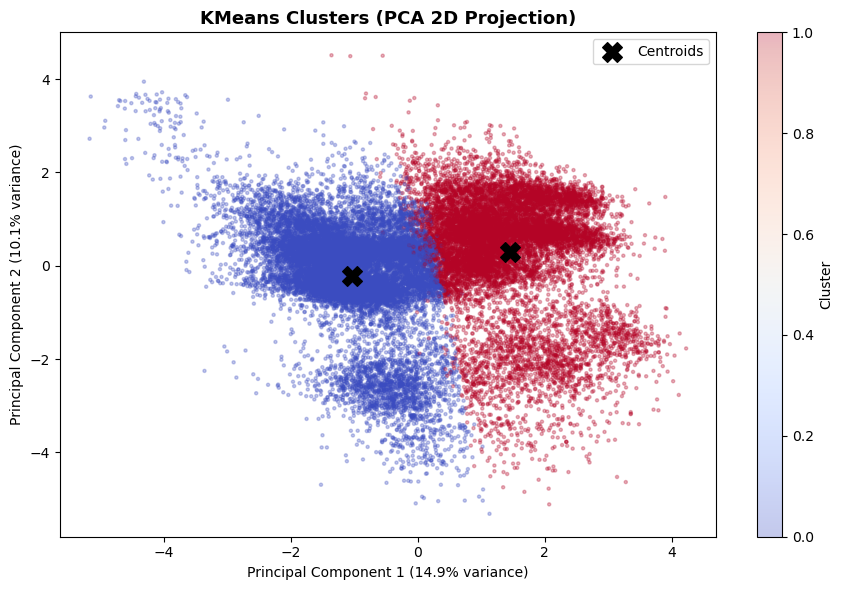

In [21]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_labels,
    cmap='coolwarm',
    alpha=0.3,
    s=5
)

# Plot centroids projected into PCA space
centres_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centres_pca[:, 0], centres_pca[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroids'
)

plt.title('KMeans Clusters (PCA 2D Projection)', fontsize=13, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
plt.show()


## Step 8 — Profile Each Cluster

We attach the cluster assignments back to the original (unscaled) DataFrame and compute the **mean of every feature per cluster**.

This tells us the typical profile of a person in each cluster — for example, whether one cluster tends to have higher education levels, more hours worked per week, or higher capital gains.

In [23]:
df_clustered = X.copy()
df_clustered['cluster'] = cluster_labels

profile = df_clustered.groupby('cluster').mean().round(2)
profile


,Age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
cluster,,,,,,,,,,,,,,
0,42.47,2.28,187073.31,10.44,10.39,2.0,6.17,0.38,3.79,0.94,1585.77,116.72,44.66,36.55
1,32.79,2.08,193606.46,10.19,9.74,3.4,5.67,2.88,3.53,0.30,400.03,48.64,35.71,36.15


### Key Feature Differences Between Clusters

We plot the mean values of the most informative features side by side to make the differences visually obvious.

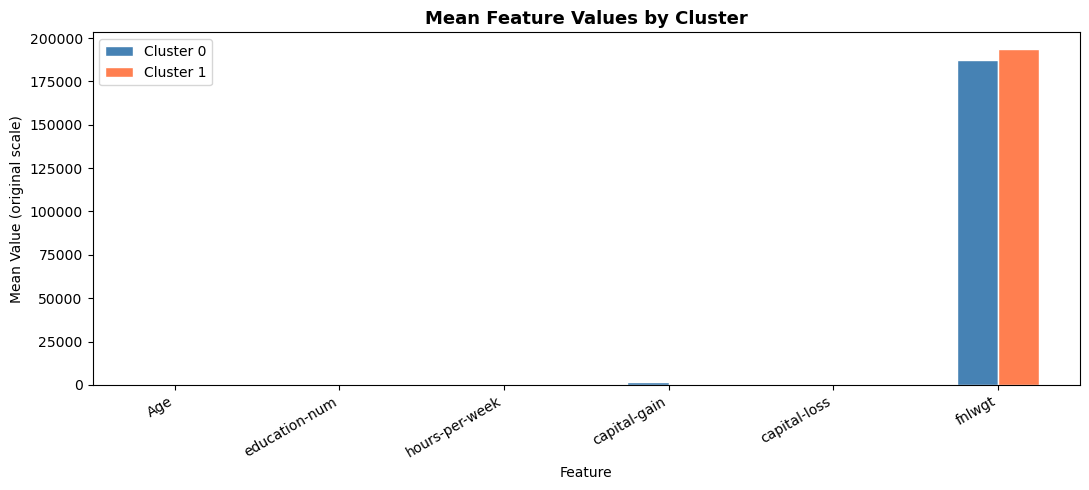

In [25]:
key_features = ['Age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'fnlwgt']

profile[key_features].T.plot(
    kind='bar',
    figsize=(11, 5),
    color=['steelblue', 'coral'],
    edgecolor='white'
)
plt.title('Mean Feature Values by Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Mean Value (original scale)')
plt.xticks(rotation=30, ha='right')
plt.legend(['Cluster 0', 'Cluster 1'])
plt.tight_layout()
plt.show()


## Step 9 — Compare Clusters Against Actual Income Labels

This is the most revealing step. We compare the cluster assignments produced by KMeans against the real `label` column that the model never saw.

**If the clusters align well with the income labels**, it means the demographic features alone contain enough signal to separate the two income groups — the model has discovered structure that matches the real-world classification.

**If they do not align well**, it means income group membership is not the dominant source of variation in this dataset — other patterns drive the clustering.

We use a **cross-tabulation** (contingency table) to see how cluster 0 and cluster 1 map onto `<=50K` (label 0) and `>50K` (label 1).

In [27]:
df_compare = pd.DataFrame({
    'cluster'    : cluster_labels,
    'true_label' : true_labels.values
})

crosstab = pd.crosstab(
    df_compare['cluster'],
    df_compare['true_label'],
    rownames=['Cluster'],
    colnames=['True Label (0=<=50K, 1=>50K)']
)
print(crosstab)


True Label (0=<=50K, 1=>50K)      0     1
Cluster                                  
0                             11149  6453
1                             11505  1055


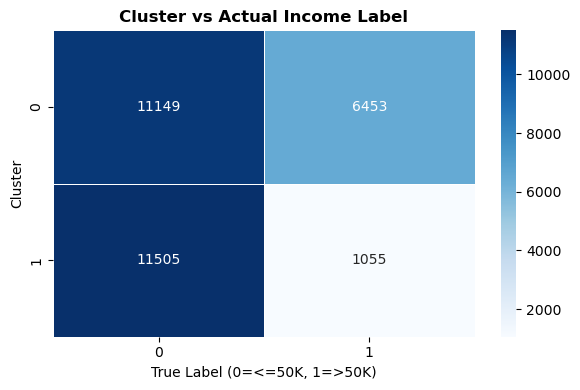

In [28]:
# Visualise as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    crosstab,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)
plt.title('Cluster vs Actual Income Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Cluster Purity

Cluster purity measures what percentage of each cluster belongs to its majority class.

A purity of 100% means every person in that cluster belongs to the same income group. A purity of 50% means the cluster is no better than random.

In [30]:
for cluster_id in [0, 1]:
    subset = df_compare[df_compare['cluster'] == cluster_id]
    majority_class = subset['true_label'].value_counts().idxmax()
    majority_count = subset['true_label'].value_counts().max()
    purity = majority_count / len(subset) * 100
    label_name = '<=50K' if majority_class == 0 else '>50K'
    print(f'Cluster {cluster_id}: {len(subset):,} people | majority class = {label_name} | purity = {purity:.1f}%')


Cluster 0: 17,602 people | majority class = <=50K | purity = 63.3%
Cluster 1: 12,560 people | majority class = <=50K | purity = 91.6%


## Step 10 — Income Distribution Within Each Cluster

A stacked bar chart shows the proportion of `<=50K` and `>50K` earners inside each cluster.

This makes it easy to see at a glance whether one cluster is predominantly high earners and the other predominantly low earners.

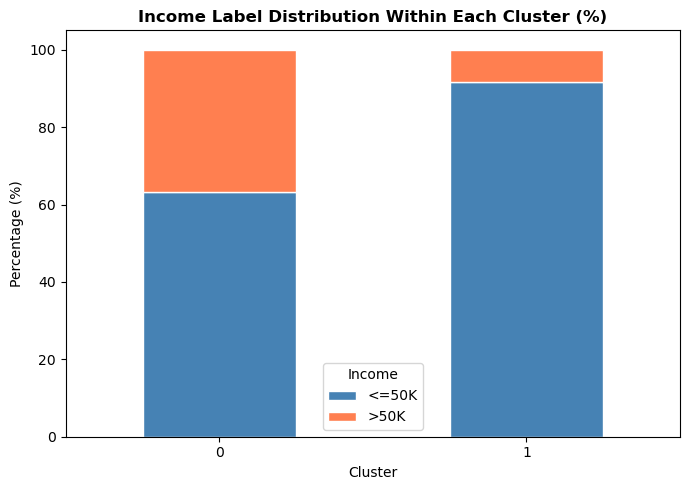

In [32]:
income_dist = df_compare.groupby(['cluster', 'true_label']).size().unstack(fill_value=0)
income_dist.columns = ['<=50K', '>50K']
income_dist_pct = income_dist.div(income_dist.sum(axis=1), axis=0) * 100

income_dist_pct.plot(
    kind='bar',
    stacked=True,
    color=['steelblue', 'coral'],
    edgecolor='white',
    figsize=(7, 5)
)
plt.title('Income Label Distribution Within Each Cluster (%)', fontsize=12, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Income')
plt.tight_layout()
plt.show()


## Summary

| Step | Action | Why |
|---|---|---|
| 1 | Import libraries | Load KMeans, PCA, and silhouette score alongside standard tools |
| 2 | Load and preprocess | Same pipeline as the classifier — encode and clean the data |
| 3 | Scale features | Euclidean distance (used by KMeans) is sensitive to feature magnitude |
| 4 | Elbow Method | Plot inertia vs k to find the bend where adding clusters stops helping |
| 5 | Silhouette scores | Numeric measure of how well-separated the clusters are |
| 6 | Fit KMeans (k=2) | Train the model and assign every person to a cluster |
| 7 | PCA visualisation | Compress 14 features to 2D so clusters can be plotted |
| 8 | Cluster profiles | Compare mean feature values per cluster to interpret what each group represents |
| 9 | Compare vs labels | Check whether the unsupervised clusters match the real income groups |
| 10 | Income distribution | Stacked bar chart of income proportions per cluster |

### Key Difference from Logistic Regression

| | Logistic Regression | KMeans Clustering |
|---|---|---|
| Type | Supervised | Unsupervised |
| Uses labels during training | Yes | No |
| Output | Predicted class (<=50K / >50K) | Cluster ID (0 / 1) |
| Goal | Predict a known target | Discover hidden structure |
| Evaluation | Accuracy, F1, ROC-AUC | Inertia, Silhouette, cluster purity |

---
*Built with scikit-learn (KMeans, PCA, StandardScaler), pandas, matplotlib, and seaborn.*